In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid", palette="colorblind", font_scale=1.1)    

## Part A: Data Preprocessing and Baseline

In [18]:
# Load dataset
df = pd.read_csv(r"data/hour.csv")
print("Shape:" , df.shape)
df.head()

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


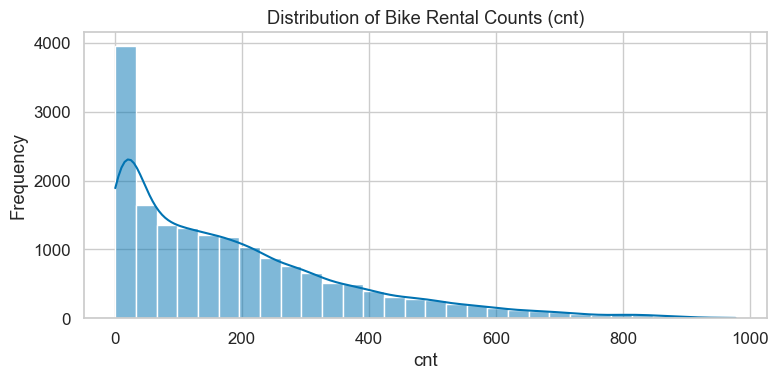

In [19]:
# Distribution of target
plt.figure(figsize=(8,4))
sns.histplot(df['cnt'], bins=30, kde=True, color='C0')
plt.title('Distribution of Bike Rental Counts (cnt)')
plt.xlabel('cnt')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Kinda follows exponential distribution**

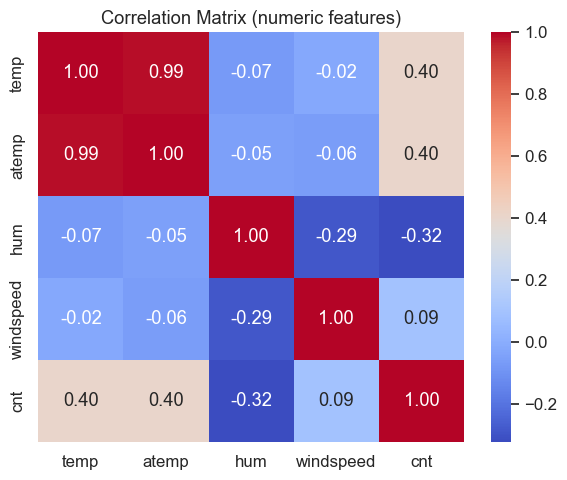

In [20]:
# Correlation heatmap for numeric features
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
plt.figure(figsize=(6,5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.show()


**We could remove either **atemp** or **temp** as both are highly correlated, anyway I've decided to keep them**

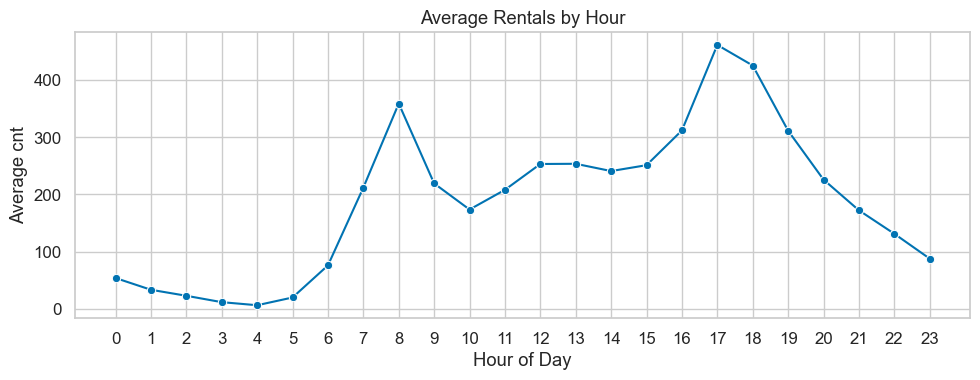

In [21]:
# Hourly trend (mean count by hour)
hourly = df.groupby('hr')['cnt'].mean().reset_index()
plt.figure(figsize=(10,4))
sns.lineplot(data=hourly, x='hr', y='cnt', marker='o')
plt.title('Average Rentals by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average cnt')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

**Averange Cnt tend to peak around 8 and 17 hours**

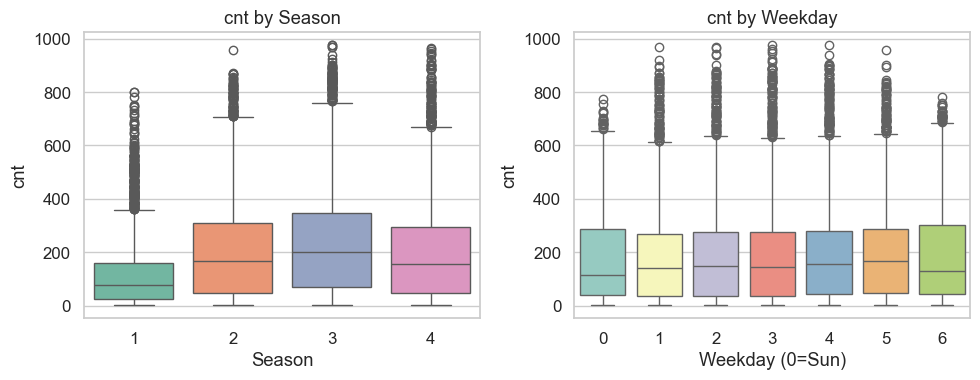

In [22]:
# Boxplots: season and weekday effects
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(x='season', y='cnt', data=df, palette='Set2')
plt.title('cnt by Season')
plt.xlabel('Season')

plt.subplot(1,2,2)
sns.boxplot(x='weekday', y='cnt', data=df, palette='Set3')
plt.title('cnt by Weekday')
plt.xlabel('Weekday (0=Sun)')
plt.tight_layout()
plt.show()

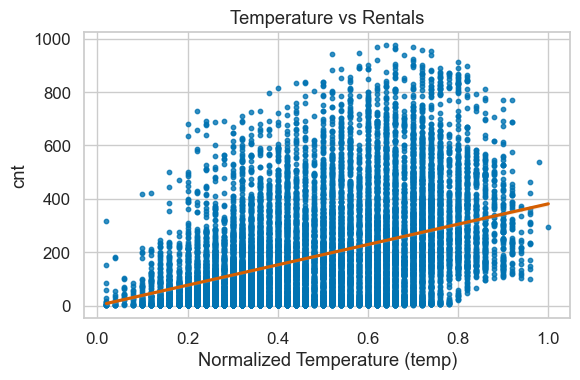

In [23]:
# temp vs cnt scatter with regression line
plt.figure(figsize=(6,4))
sns.regplot(x='temp', y='cnt', data=df, scatter_kws={'s':10}, line_kws={'color':'r'})
plt.title('Temperature vs Rentals')
plt.xlabel('Normalized Temperature (temp)')
plt.ylabel('cnt')
plt.tight_layout()
plt.show()

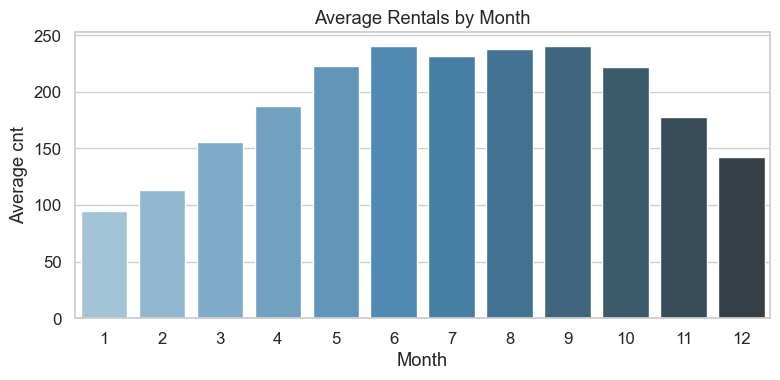

In [24]:
# Monthly average counts
mnth_avg = df.groupby('mnth')['cnt'].mean().reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=mnth_avg, x='mnth', y='cnt', palette='Blues_d')
plt.title('Average Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average cnt')
plt.tight_layout()
plt.show()

In [25]:
# Feature Cleaning
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

# One-Hot Encode Categoricals
categorical = ['season', 'weathersit', 'mnth', 'hr', 'weekday']
numeric = [c for c in df.columns if c not in categorical + ['cnt']]

X = df.drop('cnt', axis=1)
y = df['cnt']

encoder = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first'), categorical)],
    remainder='passthrough'
)

X_enc = encoder.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (13903, 53)
Test set shape: (3476, 53)


In [26]:
# Baseline Models
# Decision Tree
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
rmse_dt = np.sqrt(mean_squared_error(y_test, dt.predict(X_test)))

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))

print(f"Decision Tree RMSE: {rmse_dt:.3f}")
print(f"Linear Regression RMSE: {rmse_lr:.3f}")
baseline_model = "Decision Tree" if rmse_dt < rmse_lr else "Linear Regression"
baseline_rmse = min(rmse_dt, rmse_lr)
print(f"\nBaseline model: {baseline_model} (RMSE = {baseline_rmse:.3f})")

Decision Tree RMSE: 118.456
Linear Regression RMSE: 100.446

Baseline model: Linear Regression (RMSE = 100.446)


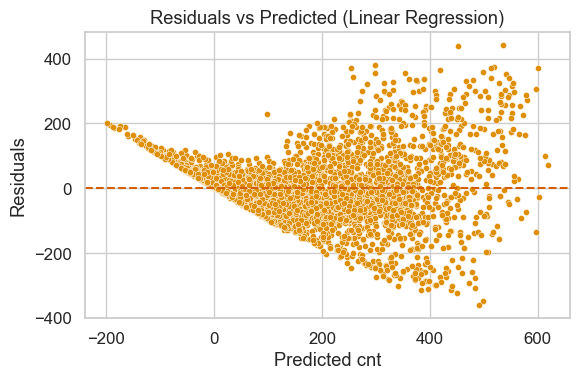

In [27]:
try:
    baseline = dt if baseline_model == "Decision Tree" else lr
    y_pred = baseline.predict(X_test)
    resid = y_test - y_pred
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=y_pred, y=resid, s=20, color='C1')
    plt.axhline(0, color='r', linestyle='--')
    plt.title(f'Residuals vs Predicted ({baseline_model})')
    plt.xlabel('Predicted cnt')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Could not plot residuals (baseline model or test set missing):", e)

## Part B: Ensemble Techniques for Bias and Variance Reduction

Train RMSEs -> Decision Tree: 119.507 | Bagging: 113.844 | GradientBoosting: 63.928
Test  RMSEs -> Decision Tree: 118.456 | Bagging: 112.265 | GradientBoosting: 64.482
Bagging improvement vs DT: 5.23%
Boosting improvement vs DT: 45.56%


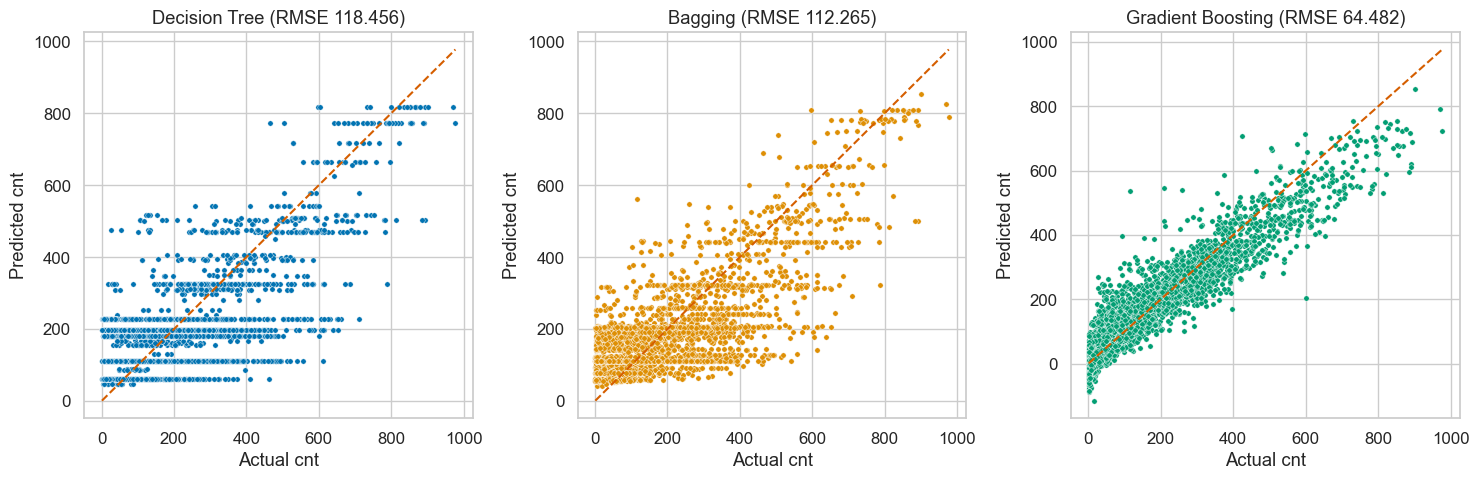

In [28]:
# Bagging (Variance Reduction) - increase estimators to 100 for stability
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=6, random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
bag.fit(X_train, y_train)
rmse_bag = np.sqrt(mean_squared_error(y_test, bag.predict(X_test)))

# Gradient Boosting (Bias Reduction)
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)
rmse_gbr = np.sqrt(mean_squared_error(y_test, gbr.predict(X_test)))

# Recompute baseline DT test RMSE (safe to recompute)
rmse_dt = np.sqrt(mean_squared_error(y_test, dt.predict(X_test)))

# Train RMSEs (to inspect bias/variance)
rmse_dt_train = np.sqrt(mean_squared_error(y_train, dt.predict(X_train)))
rmse_bag_train = np.sqrt(mean_squared_error(y_train, bag.predict(X_train)))
rmse_gbr_train = np.sqrt(mean_squared_error(y_train, gbr.predict(X_train)))

print(f"Train RMSEs -> Decision Tree: {rmse_dt_train:.3f} | Bagging: {rmse_bag_train:.3f} | GradientBoosting: {rmse_gbr_train:.3f}")
print(f"Test  RMSEs -> Decision Tree: {rmse_dt:.3f} | Bagging: {rmse_bag:.3f} | GradientBoosting: {rmse_gbr:.3f}")

imp_bag = 100.0 * (rmse_dt - rmse_bag) / rmse_dt if rmse_dt != 0 else 0.0
imp_gbr = 100.0 * (rmse_dt - rmse_gbr) / rmse_dt if rmse_dt != 0 else 0.0
print(f"Bagging improvement vs DT: {imp_bag:.2f}%")
print(f"Boosting improvement vs DT: {imp_gbr:.2f}%")

# Visual comparisons
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.scatterplot(x=y_test, y=dt.predict(X_test), s=15, color='C0')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f"Decision Tree (RMSE {rmse_dt:.3f})")
plt.xlabel("Actual cnt"); plt.ylabel("Predicted cnt")

plt.subplot(1,3,2)
sns.scatterplot(x=y_test, y=bag.predict(X_test), s=15, color='C1')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f"Bagging (RMSE {rmse_bag:.3f})")
plt.xlabel("Actual cnt"); plt.ylabel("Predicted cnt")

plt.subplot(1,3,3)
sns.scatterplot(x=y_test, y=gbr.predict(X_test), s=15, color='C2')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f"Gradient Boosting (RMSE {rmse_gbr:.3f})")
plt.xlabel("Actual cnt"); plt.ylabel("Predicted cnt")

plt.tight_layout()
plt.show()

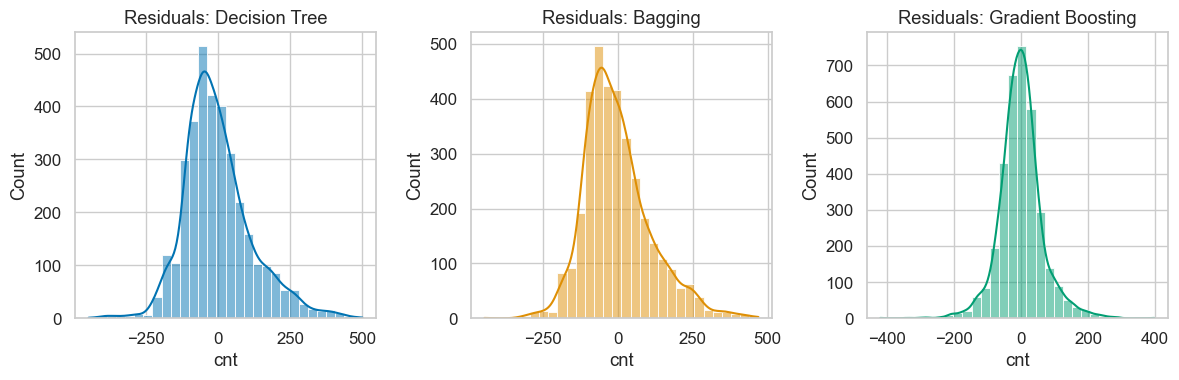

In [29]:
# Residual distributions
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(y_test - dt.predict(X_test), bins=30, kde=True, color='C0')
plt.title("Residuals: Decision Tree")

plt.subplot(1,3,2)
sns.histplot(y_test - bag.predict(X_test), bins=30, kde=True, color='C1')
plt.title("Residuals: Bagging")

plt.subplot(1,3,3)
sns.histplot(y_test - gbr.predict(X_test), bins=30, kde=True, color='C2')
plt.title("Residuals: Gradient Boosting")

plt.tight_layout()
plt.show()

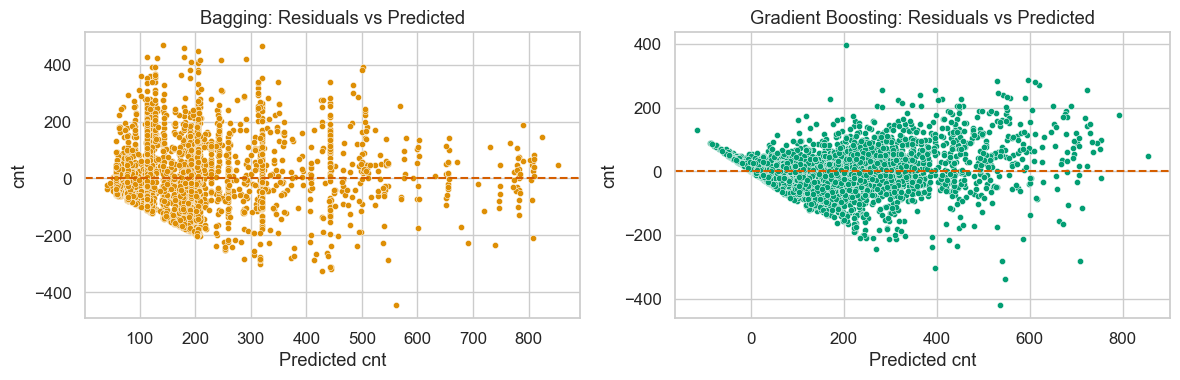

In [30]:
# Residuals vs Predicted (side-by-side)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.scatterplot(x=bag.predict(X_test), y=(y_test - bag.predict(X_test)), s=20, color='C1')
plt.axhline(0, color='r', linestyle='--')
plt.title('Bagging: Residuals vs Predicted')
plt.xlabel('Predicted cnt')

plt.subplot(1,2,2)
sns.scatterplot(x=gbr.predict(X_test), y=(y_test - gbr.predict(X_test)), s=20, color='C2')
plt.axhline(0, color='r', linestyle='--')
plt.title('Gradient Boosting: Residuals vs Predicted')
plt.xlabel('Predicted cnt')

plt.tight_layout()
plt.show()

**Why Bagging and Boosting Reduce Variance (and Why Boosting Does More)**

For a regressor $\hat{f}(x)$, prediction error can be decomposed as:

$
\mathbb{E}[(y - \hat{f}(x))^2] = (\text{Bias}[\hat{f}(x)])^2 + \text{Var}[\hat{f}(x)] + \sigma^2
$

---

**Bagging**
Bagging averages predictions from multiple models trained on bootstrap samples:

$
\hat{f}_{\text{bag}}(x) = \frac{1}{M}\sum_{m=1}^M \hat{f}_m(x)
$

If each model has variance \( \sigma^2 \) and correlation \( \rho \), then

$
\text{Var}[\hat{f}_{\text{bag}}(x)] = \rho\sigma^2 + \frac{(1-\rho)}{M}\sigma^2
$

**Variance ↓**, **Bias ≈ same** → useful for high-variance learners like trees.

---

**Boosting**
Boosting builds models sequentially:

$
\hat{f}_M(x) = \sum_{m=1}^{M} \gamma_m h_m(x)
$

Each new model corrects residuals of the previous one, effectively performing gradient descent on the loss.

**Bias ↓↓**, **Variance ↓** → improves both accuracy and stability.

---

**Summary**
| Method | Bias | Variance | Goal |
|:--|:--|:--|:--|
| Bagging | ≈ same | ↓↓ | Reduce variance |
| Boosting | ↓↓ | ↓ | Reduce bias *and* variance |

**Boosting does more** — it not only stabilizes predictions but also systematically corrects bias.

## Part C: Stacking for Optimal Performance

In [31]:
# Define Level-0 learners
knn = KNeighborsRegressor(n_neighbors=5)
bag_lvl = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=6, random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
gbr_lvl = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

# Construct Stacking Regressor (Level-1 = Ridge)
stack = StackingRegressor(
    estimators=[('knn', knn), ('bag', bag_lvl), ('gbr', gbr_lvl)],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False,
)

# Fit stacking model
stack.fit(X_train, y_train)

# Evaluate
rmse_stack_train = np.sqrt(mean_squared_error(y_train, stack.predict(X_train)))
rmse_stack_test = np.sqrt(mean_squared_error(y_test, stack.predict(X_test)))

print(f"Stacking Train RMSE: {rmse_stack_train:.3f}")
print(f"Stacking Test  RMSE: {rmse_stack_test:.3f}")
print(f"Decision Tree Test RMSE: {rmse_dt:.3f}")
print(f"Bagging Test RMSE:       {rmse_bag:.3f}")
print(f"GradientBoosting Test RMSE: {rmse_gbr:.3f}")

Stacking Train RMSE: 57.239
Stacking Test  RMSE: 60.285
Decision Tree Test RMSE: 118.456
Bagging Test RMSE:       112.265
GradientBoosting Test RMSE: 64.482


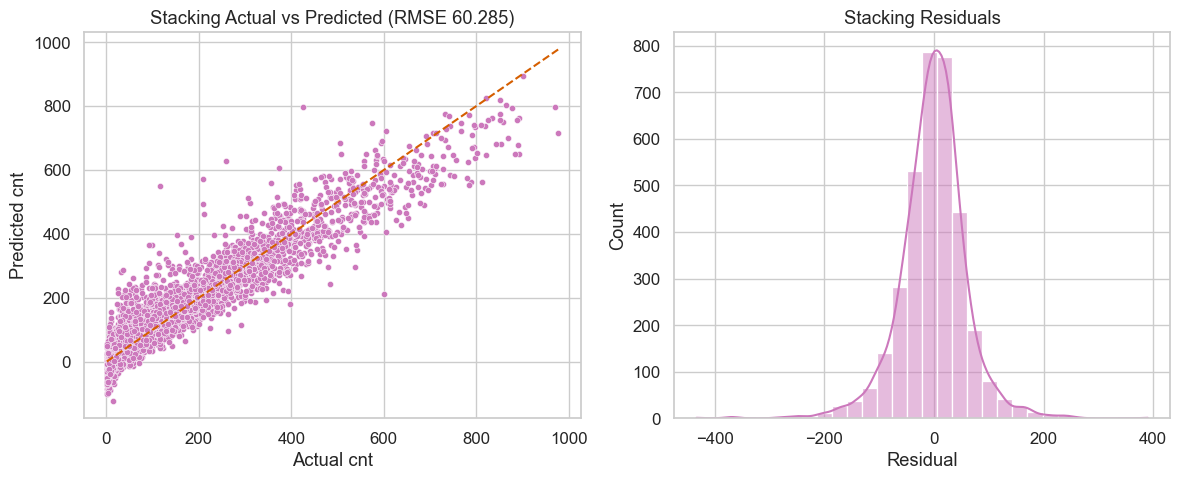

In [32]:
# Diagnostic plots: Actual vs Predicted and residuals
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=y_test, y=stack.predict(X_test), s=20, color='C4')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual cnt'); plt.ylabel('Predicted cnt')
plt.title(f'Stacking Actual vs Predicted (RMSE {rmse_stack_test:.3f})')

plt.subplot(1,2,2)
res_stack = y_test - stack.predict(X_test)
sns.histplot(res_stack, bins=30, kde=True, color='C4')
plt.title('Stacking Residuals')
plt.xlabel('Residual')

plt.tight_layout()
plt.show()

## Final Analysis

In [33]:
# Build results table (use existing variables from earlier cells)
results = pd.DataFrame({
    "Model": [
        f"Baseline ({baseline_model})",
        "Bagging Regressor",
        "Gradient Boosting",
        "Stacking Regressor"
    ],
    "RMSE": [
        float(baseline_rmse) if 'baseline_rmse' in globals() else float(min(rmse_dt, rmse_lr)),
        float(rmse_bag),
        float(rmse_gbr),
        float(rmse_stack_test)
    ]
})

# Display table
print("RMSE Summary:")
print(results.to_string(index=False))

RMSE Summary:
                       Model       RMSE
Baseline (Linear Regression) 100.445946
           Bagging Regressor 112.265023
           Gradient Boosting  64.482188
          Stacking Regressor  60.285364


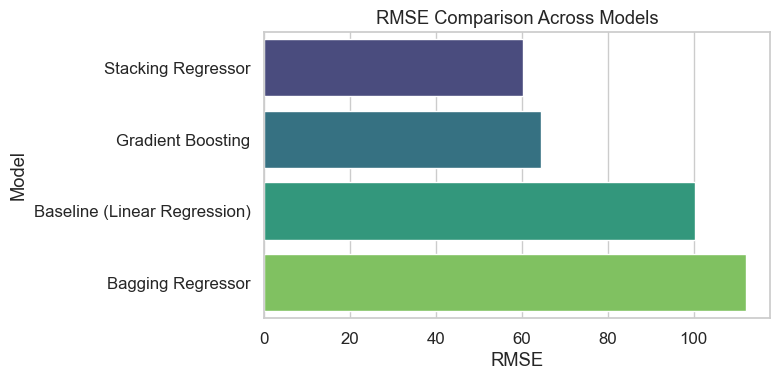


Best-performing model: Stacking Regressor (RMSE = 60.285)


In [35]:
# Plot comparison
plt.figure(figsize=(8,4))
sns.barplot(data=results.sort_values("RMSE"), x="RMSE", y="Model", palette="viridis")
plt.title("RMSE Comparison Across Models")
plt.xlabel("RMSE")
plt.tight_layout()
plt.show()

# Identify best model and short conclusion
best = results.loc[results["RMSE"].idxmin()]
print(f"\nBest-performing model: {best['Model']} (RMSE = {best['RMSE']:.3f})")

**Why Stacking Can Outperform Bagging and Boosting**

Stacking combines **diverse base models** (Level-0) and learns how to best weight them using a **meta-learner** (Level-1).

---

**Mechanism**

Each base model $h_i(x)$ makes its own prediction.  
The meta-learner $g(\cdot)$ then learns to combine them:

$
\hat{f}_{\text{stack}}(x) = g\big(h_1(x), h_2(x), \dots, h_k(x)\big)
$

Unlike bagging or boosting, which average or sequentially correct predictions,  
stacking **learns** how to mix models in a data-driven way.

---

**Intuition**

- **Bagging** → reduces variance by averaging similar models.  
- **Boosting** → reduces bias by focusing on residual errors.  
- **Stacking** → leverages *model diversity* (e.g., trees, KNN, linear) to minimize both bias and variance simultaneously.

Because base learners capture **different aspects of the data**,  
the meta-learner can **learn optimal weights** that exploit their strengths and offset weaknesses.

---

**Summary**

| Method | Bias | Variance | Diversity | How It Combines Models |
|:--|:--|:--|:--|:--|
| Bagging | ≈ same | ↓↓ | Low (same model type) | Simple average |
| Boosting | ↓↓ | ↓ | Medium (weighted trees) | Sequential correction |
| Stacking | ↓ | ↓ | **High (heterogeneous models)** | **Learned combination (meta-model)** |

**Stacking wins** by using *diverse learners + learned blending* — achieving the best bias–variance balance.